In [2]:
import pandas as pd

# ECOS에서 받은 CSV 로드 (세로형, 컬럼: 변환=날짜, 원자료=환율값)
df = pd.read_csv("../data/exchange_rate.csv", encoding="utf-8-sig")

# 컬럼 이름을 알아보기 쉽게 변경
df = df.rename(columns={"변환": "date", "원자료": "usd_krw"})

# 콤마 제거 후 숫자로 변환 (예: "1,383.80" -> 1383.80)
df["usd_krw"] = df["usd_krw"].astype(str).str.replace(",", "").astype(float)

# 날짜 형식 변환
df["date"] = pd.to_datetime(df["date"], format="%Y/%m/%d")
df = df.sort_values("date").reset_index(drop=True)

# 확인
print(df.info())
print()
print(df.head())
print()
print(df.tail())
print()
print("총 데이터 개수:", len(df))

# 정제된 데이터 별도 저장
df.to_csv("../data/exchange_rate_clean.csv", index=False, encoding="utf-8-sig")

<class 'pandas.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     532 non-null    datetime64[us]
 1   usd_krw  530 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 8.4 KB
None

        date  usd_krw
0 2024-07-01   1383.8
1 2024-07-02   1386.9
2 2024-07-03   1385.8
3 2024-07-04   1381.0
4 2024-07-05   1381.4

          date  usd_krw
527 2026-08-28   1379.9
528 2026-08-31   1368.0
529 2026-09-01   1375.0
530 2026-09-02   1359.2
531 2026-09-03   1357.5

총 데이터 개수: 532


In [3]:
# 결측치가 있는 행 찾기
missing = df[df["usd_krw"].isna()]
print("결측치 개수:", len(missing))
print()
print(missing)


결측치 개수: 2

          date  usd_krw
123 2024-12-31      NaN
366 2025-12-31      NaN


In [4]:
# 결측치 처리: 직전 값으로 채우기 (전일 종가 유지)
# 이유: 12/31이 반휴장일 등으로 매매기준율이 고시되지 않은 것으로 추정.
#      하루짜리 결측이라 전일 값으로 대체해도 추세 왜곡이 거의 없음.
df["usd_krw"] = df["usd_krw"].ffill()

# 처리 후 재확인
print("처리 후 결측치 개수:", df["usd_krw"].isna().sum())
print()
print(df[df["date"].isin(["2024-12-30", "2024-12-31", "2025-12-30", "2025-12-31"])])

# 정제된 데이터 다시 저장 (결측치 처리 반영)
df.to_csv("../data/exchange_rate_clean.csv", index=False, encoding="utf-8-sig")

처리 후 결측치 개수: 0

Empty DataFrame
Columns: [date, usd_krw]
Index: []


In [5]:
# 결측치 처리: 직전 값으로 채우기 (전일 종가 유지)
df["usd_krw"] = df["usd_krw"].ffill()

# 처리 후 재확인
print("처리 후 결측치 개수:", df["usd_krw"].isna().sum())
print()

# 날짜를 문자열로 변환해서 비교 (datetime vs 문자열 비교 문제 해결)
check_dates = df[df["date"].dt.strftime("%Y-%m-%d").isin(
    ["2024-12-30", "2024-12-31", "2025-12-30", "2025-12-31"]
)]
print(check_dates)

# 정제된 데이터 다시 저장
df.to_csv("../data/exchange_rate_clean.csv", index=False, encoding="utf-8-sig")

처리 후 결측치 개수: 0

          date  usd_krw
122 2024-12-30   1472.3
123 2024-12-31   1472.3
365 2025-12-30   1439.5
366 2025-12-31   1439.5


In [6]:
# 이상치 확인 (IQR 방식 - 통계적으로 벗어난 값 탐지)
Q1 = df["usd_krw"].quantile(0.25)
Q3 = df["usd_krw"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["usd_krw"] < lower) | (df["usd_krw"] > upper)]

print(f"Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}")
print(f"정상 범위: {lower:.1f} ~ {upper:.1f}")
print(f"이상치 개수: {len(outliers)}")
print()
print(outliers[["date", "usd_krw"]])

Q1: 1385.0, Q3: 1468.3, IQR: 83.4
정상 범위: 1259.9 ~ 1593.4
이상치 개수: 0

Empty DataFrame
Columns: [date, usd_krw]
Index: []


In [7]:
# 1. 이동평균 (20일, 60일) - 단기/중기 추세 파악
df["ma20"] = df["usd_krw"].rolling(window=20).mean()
df["ma60"] = df["usd_krw"].rolling(window=60).mean()

# 2. 일간 변화율 (%) - 전일 대비 얼마나 변했는지
df["pct_change"] = df["usd_krw"].pct_change() * 100

# 3. 변동성 (20일 구간 표준편차) - 최근 변동폭이 큰지 작은지
df["volatility_20"] = df["usd_krw"].rolling(window=20).std()

# 확인
print(df[["date", "usd_krw", "ma20", "ma60", "pct_change", "volatility_20"]].tail(10))

# 4. 진짜 "급등/급락"일 찾기 - 일간 변화율 기준 상위/하위 5일
print()
print("=== 하루 변화율이 가장 컸던 날 TOP 5 (급등) ===")
print(df.nlargest(5, "pct_change")[["date", "usd_krw", "pct_change"]])
print()
print("=== 하루 변화율이 가장 작았던 날 TOP 5 (급락) ===")
print(df.nsmallest(5, "pct_change")[["date", "usd_krw", "pct_change"]])

# 정제+분석 결과 저장
df.to_csv("../data/exchange_rate_clean.csv", index=False, encoding="utf-8-sig")

          date  usd_krw      ma20         ma60  pct_change  volatility_20
522 2026-08-21   1386.2  1423.055  1485.961667   -0.702006      21.226882
523 2026-08-24   1383.2  1419.290  1484.011667   -0.216419      21.287009
524 2026-08-25   1382.7  1415.165  1482.145000   -0.036148      19.868496
525 2026-08-26   1386.3  1411.775  1480.170000    0.260360      18.620585
526 2026-08-27   1381.5  1408.525  1477.980000   -0.346245      17.899276
527 2026-08-28   1379.9  1406.620  1475.661667   -0.115816      18.840511
528 2026-08-31   1368.0  1403.245  1472.928333   -0.862381      19.431349
529 2026-09-01   1375.0  1400.520  1469.861667    0.511696      19.377024
530 2026-09-02   1359.2  1397.030  1467.073333   -1.149091      20.243962
531 2026-09-03   1357.5  1393.780  1464.153333   -0.125074      21.137634

=== 하루 변화율이 가장 컸던 날 TOP 5 (급등) ===
          date  usd_krw  pct_change
405 2026-03-03   1485.7    3.173611
63  2024-10-04   1349.5    1.895198
469 2026-06-05   1559.0    1.762402
104 20

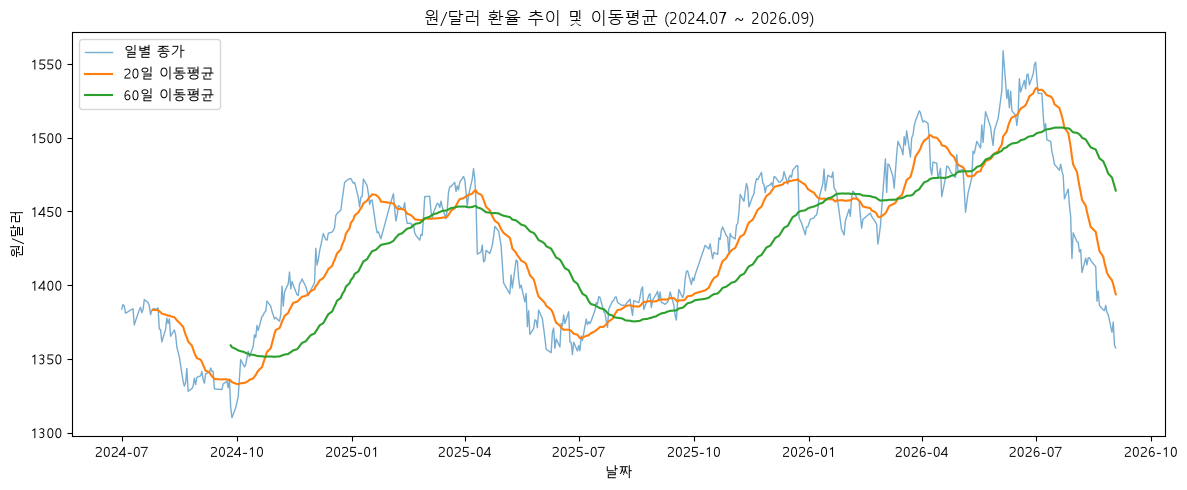

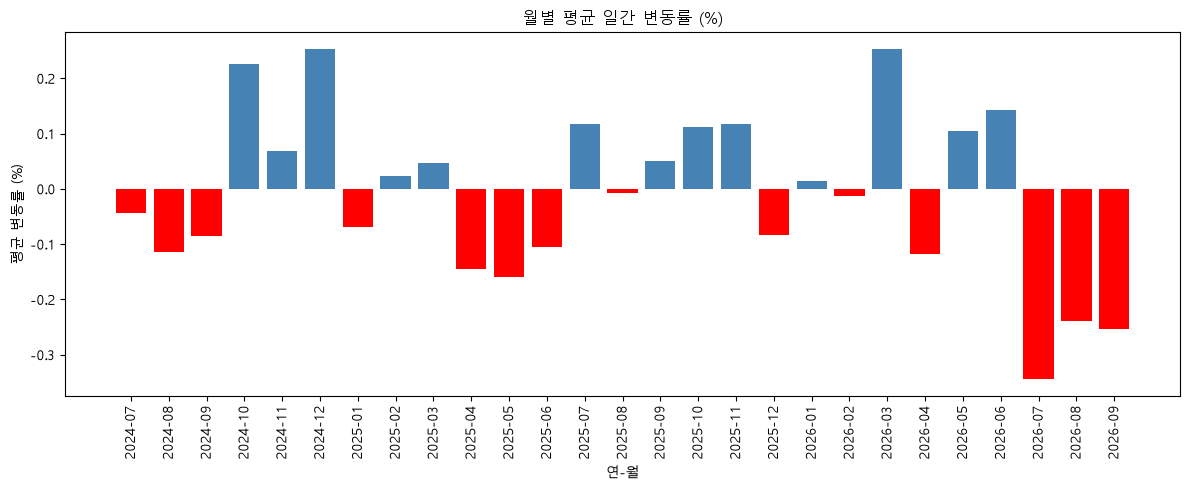

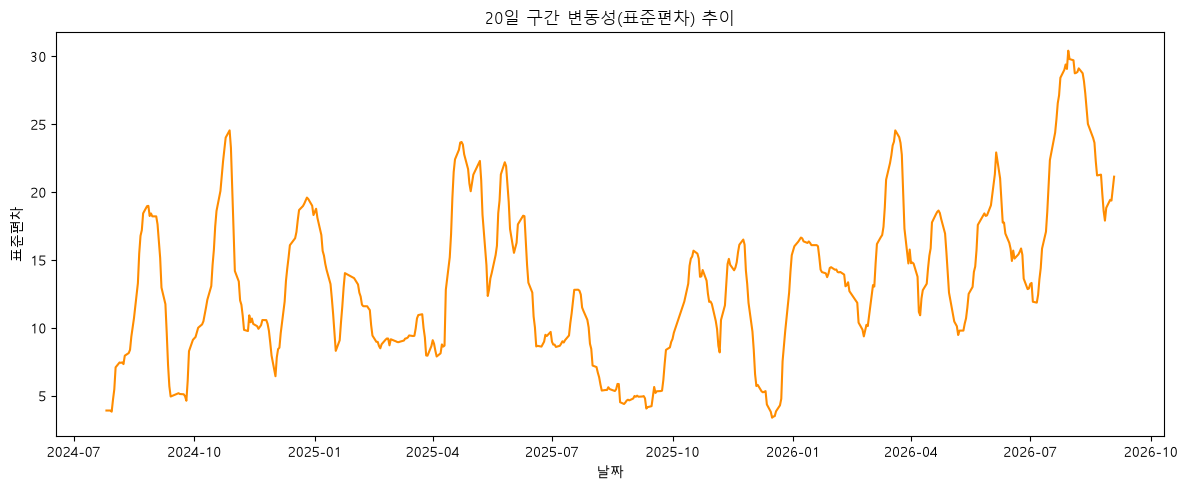

그래프 3개 저장 완료: output/01_price_trend_ma.png, 02_monthly_change.png, 03_volatility.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows: 맑은 고딕)
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

import os
os.makedirs("../output", exist_ok=True)

# 1. 원본 추세 + 이동평균 비교 그래프
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["usd_krw"], label="일별 종가", linewidth=1, alpha=0.6)
plt.plot(df["date"], df["ma20"], label="20일 이동평균", linewidth=1.5)
plt.plot(df["date"], df["ma60"], label="60일 이동평균", linewidth=1.5)
plt.title("원/달러 환율 추이 및 이동평균 (2024.07 ~ 2026.09)")
plt.xlabel("날짜")
plt.ylabel("원/달러")
plt.legend()
plt.tight_layout()
plt.savefig("../output/01_price_trend_ma.png", dpi=150)
plt.show()

# 2. 월별 평균 변동률 막대그래프
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby("year_month")["pct_change"].mean()

plt.figure(figsize=(12, 5))
colors = ["red" if v < 0 else "steelblue" for v in monthly.values]
plt.bar(monthly.index.astype(str), monthly.values, color=colors)
plt.title("월별 평균 일간 변동률 (%)")
plt.xlabel("연-월")
plt.ylabel("평균 변동률 (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../output/02_monthly_change.png", dpi=150)
plt.show()

# 3. 변동성(20일 표준편차) 추이 그래프
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["volatility_20"], color="darkorange")
plt.title("20일 구간 변동성(표준편차) 추이")
plt.xlabel("날짜")
plt.ylabel("표준편차")
plt.tight_layout()
plt.savefig("../output/03_volatility.png", dpi=150)
plt.show()

print("그래프 3개 저장 완료: output/01_price_trend_ma.png, 02_monthly_change.png, 03_volatility.png")

In [9]:
# 월별 평균 변동률 중 하락폭이 가장 컸던 달 TOP 5
print("=== 월평균 하락폭이 가장 컸던 달 TOP 5 ===")
print(monthly.sort_values().head(5))
print()
print("=== 월평균 상승폭이 가장 컸던 달 TOP 5 ===")
print(monthly.sort_values(ascending=False).head(5))

=== 월평균 하락폭이 가장 컸던 달 TOP 5 ===
year_month
2026-07   -0.344792
2026-09   -0.254156
2026-08   -0.239085
2025-05   -0.160360
2025-04   -0.144233
Freq: M, Name: pct_change, dtype: float64

=== 월평균 상승폭이 가장 컸던 달 TOP 5 ===
year_month
2024-12    0.253103
2026-03    0.252870
2024-10    0.225158
2026-06    0.143114
2025-11    0.117514
Freq: M, Name: pct_change, dtype: float64
